# Output BAB 4.2 — Hasil Pembentukan Label UNOSAT dan Dataset Tile

Notebook ini khusus membuat artefak untuk subbab **4.2 Hasil Pembentukan Label UNOSAT dan Dataset Tile** sesuai `TODO_BAB_4_Lengkap.md` dan `TODO_BAB_4_Checklist_Output.md`. Output mencakup statistik label, distribusi tile, panel mask UNOSAT, mapping fungsi layer UNOSAT, contoh tile positif/background, narasi interpretasi, dan checklist cakupan TODO.


## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper toleran untuk membaca tile/raster.


In [10]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [11]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.2 Statistik Label UNOSAT

Menghitung jumlah piksel valid, piksel banjir, non-banjir, water/river, persentase banjir, dan class imbalance dari tile 7-channel per wilayah.


saved table: outputs/bab4/tables/4_2_label_mask_tile_stats.csv (11 rows)


,region,tiles,pixels_total,valid_pixels,flood_pixels,non_flood_pixels,water_river_pixels,valid_pct,flood_pct_of_valid,water_river_pct_of_valid,s2_valid_pct_of_valid,class_imbalance_non_flood_to_flood,status
0,Aceh_Besar,518,135790592,106956513,4966404,101990109,2607154,78.7658,4.6434,2.4376,80.5364,20.5360,ok
1,Aceh_Tamiang,465,121896960,82307919,3514376,78793543,4407206,67.5225,4.2698,5.3545,0.0008,22.4204,ok
2,Aceh_Timur,1063,278659072,206802875,11748572,195054303,9510741,74.2136,5.6810,4.5989,53.8605,16.6024,ok
3,Aceh_Utara,493,129236992,102158650,18781032,83377618,12835738,79.0475,18.3842,12.5645,79.5878,4.4395,ok
4,Agam,278,72876032,54576695,1054938,53521757,0,74.8898,1.9329,0.0000,0.0000,50.7345,ok
5,Banda_Aceh,16,4194304,2532433,153775,2378658,75817,60.3779,6.0722,2.9938,83.8523,15.4684,ok
6,Bireuen,303,79429632,67149979,3740370,63409609,2439065,84.5402,5.5702,3.6323,87.9336,16.9528,ok
7,Langsa,41,10747904,7395290,471267,6924023,740496,68.8068,6.3725,10.0131,0.0000,14.6924,ok
8,Pasaman_Barat,522,136839168,115359798,1304882,114054916,0,84.3032,1.1311,0.0000,0.0022,87.4063,ok
9,Pidie,572,149946368,110864777,6514184,104350593,3026288,73.9363,5.8758,2.7297,95.8625,16.0190,ok


saved figure: outputs/bab4/figures/4_2_flood_label_distribution.png


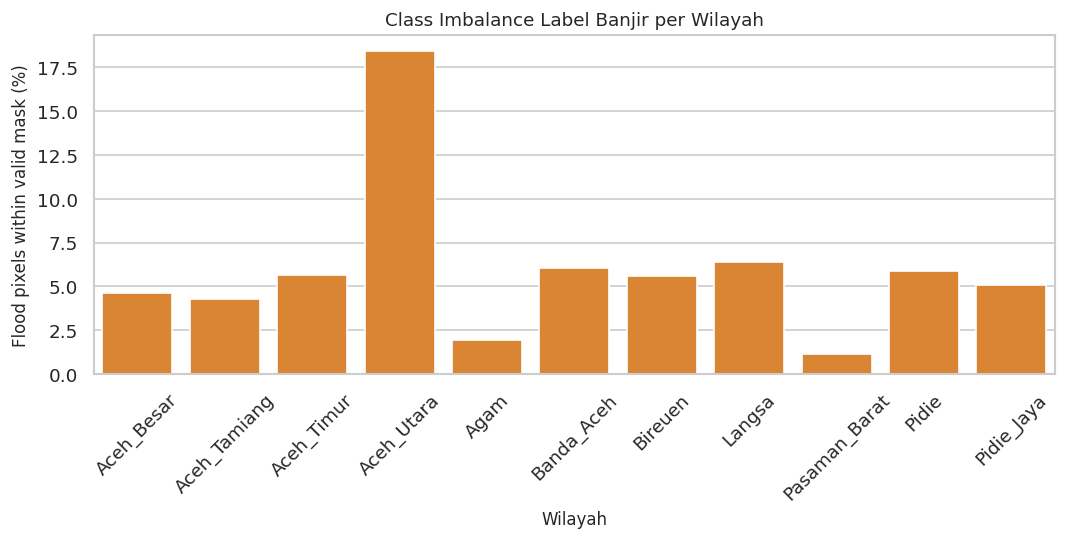

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_2_flood_label_distribution.png')

In [12]:
label_rows = []
for region in REGIONS:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    files = sorted(tile_dir.glob("*.npz"))
    total = valid = flood = water = s2_valid = 0
    for path in files:
        z = load_npz(path)
        y = np.asarray(z["y"])[0] > 0
        valid_mask = np.asarray(z.get("valid_mask", np.ones_like(y)[None]))[0] > 0
        water_mask = np.asarray(z.get("water_river_mask", np.zeros_like(y)[None]))[0] > 0
        s2_mask = np.asarray(z.get("s2_valid_mask", np.zeros_like(y)[None]))[0] > 0
        total += y.size
        valid += int(valid_mask.sum())
        flood += int((y & valid_mask).sum())
        water += int((water_mask & valid_mask).sum())
        s2_valid += int((s2_mask & valid_mask).sum())
    label_rows.append({
        "region": region,
        "tiles": len(files),
        "pixels_total": total,
        "valid_pixels": valid,
        "flood_pixels": flood,
        "non_flood_pixels": max(valid - flood, 0),
        "water_river_pixels": water,
        "valid_pct": pct(valid, total),
        "flood_pct_of_valid": pct(flood, valid),
        "water_river_pct_of_valid": pct(water, valid),
        "s2_valid_pct_of_valid": pct(s2_valid, valid),
        "class_imbalance_non_flood_to_flood": round(safe_div(max(valid - flood, 0), flood), 4) if flood else np.inf,
        "status": "ok" if files else "missing_tiles",
    })
label_stats = pd.DataFrame(label_rows)
save_table(label_stats, "4_2_label_mask_tile_stats.csv")

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = label_stats[label_stats["status"].eq("ok")]
if not plot_df.empty:
    sns.barplot(data=plot_df, x="region", y="flood_pct_of_valid", ax=ax, color="#F58518")
    ax.set_ylabel("Flood pixels within valid mask (%)")
    ax.set_xlabel("Wilayah")
    ax.tick_params(axis="x", rotation=45)
    ax.set_title("Class Imbalance Label Banjir per Wilayah")
else:
    ax.text(0.5, 0.5, "No label data", ha="center", va="center")
    ax.axis("off")
save_fig(fig, "4_2_flood_label_distribution.png")


## 4.2 Distribusi Dataset Tile

Meringkas jumlah tile per family, split, dan wilayah untuk menjelaskan distribusi dataset dan class imbalance level tile.


In [13]:
tile_rows = []
split_rows = []

def region_from_tile_name(path: Path) -> str:
    stem = path.stem
    for region in sorted(REGIONS, key=len, reverse=True):
        if stem.startswith(region + "_"):
            return region
    return stem.split("_r", 1)[0]


def tile_label_counts(path: Path) -> dict:
    z = load_npz(path)
    y = np.asarray(z["y"])[0] > 0
    valid = np.asarray(z.get("valid_mask", np.ones_like(y)[None]))[0] > 0
    flood_pixels = int((y & valid).sum())
    valid_pixels = int(valid.sum())
    return {
        "flood_pixels_valid": flood_pixels,
        "valid_pixels": valid_pixels,
        "is_positive_tile": flood_pixels > 0,
        "is_background_tile": flood_pixels == 0 and valid_pixels > 0,
    }

# Tabel wajib TODO: total tile, tile positif, tile background, dan rasio per wilayah.
for region in REGIONS:
    files = sorted((DATASET / "tiles" / "7ch" / "by_region" / region).glob("*.npz"))
    positive = 0
    background = 0
    valid_tile = 0
    flood_pixels = 0
    valid_pixels = 0
    for path in files:
        try:
            counts = tile_label_counts(path)
        except Exception:
            continue
        valid_tile += int(counts["valid_pixels"] > 0)
        positive += int(counts["is_positive_tile"])
        background += int(counts["is_background_tile"])
        flood_pixels += counts["flood_pixels_valid"]
        valid_pixels += counts["valid_pixels"]
    tile_rows.append({
        "region": region,
        "total_tile": len(files),
        "valid_tile": valid_tile,
        "tile_positive": positive,
        "tile_background": background,
        "positive_tile_pct": pct(positive, len(files)),
        "background_tile_pct": pct(background, len(files)),
        "positive_to_background_ratio": round(safe_div(positive, background), 4) if background else np.inf,
        "background_to_positive_ratio": round(safe_div(background, positive), 4) if positive else np.inf,
        "flood_pixels_valid": flood_pixels,
        "valid_pixels": valid_pixels,
        "flood_pct_of_valid": pct(flood_pixels, valid_pixels),
        "status": "ok" if files else "missing_tiles",
    })

tile_distribution = pd.DataFrame(tile_rows)
save_table(tile_distribution, "4_2_tile_distribution_by_split_region.csv")

# Tabel tambahan: jumlah tile berdasarkan split/family, dipakai untuk audit struktur dataset.
for family in ["7ch", "procanet"]:
    family_dir = DATASET / "tiles" / family
    for split in ["train", "val", "test"]:
        split_path = family_dir / split
        if not split_path.exists():
            continue
        counts = Counter()
        nested_files = sorted(split_path.glob("*/*.npz"))
        flat_files = sorted(split_path.glob("*.npz"))
        if nested_files:
            for path in nested_files:
                counts[path.parent.name] += 1
        for path in flat_files:
            counts[region_from_tile_name(path)] += 1
        for region, count in sorted(counts.items()):
            split_rows.append({"tile_family": family, "split": split, "region": region, "tile_count": count})

    by_region_dir = family_dir / "by_region"
    for region_dir in sorted(by_region_dir.glob("*")):
        if region_dir.is_dir():
            split_rows.append({"tile_family": family, "split": "by_region", "region": region_dir.name, "tile_count": len(list(region_dir.glob("*.npz")))})

split_distribution = pd.DataFrame(split_rows, columns=["tile_family", "split", "region", "tile_count"])
if not split_distribution.empty:
    split_distribution = split_distribution.sort_values(["tile_family", "split", "region"])
save_table(split_distribution, "4_2_tile_count_by_split_region.csv")


saved table: outputs/bab4/tables/4_2_tile_distribution_by_split_region.csv (11 rows)


,region,total_tile,valid_tile,tile_positive,tile_background,positive_tile_pct,background_tile_pct,positive_to_background_ratio,background_to_positive_ratio,flood_pixels_valid,valid_pixels,flood_pct_of_valid,status
0,Aceh_Besar,518,476,266,210,51.3514,40.5405,1.2667,0.7895,4966404,106956513,4.6434,ok
1,Aceh_Tamiang,465,358,207,151,44.5161,32.4731,1.3709,0.7295,3514376,82307919,4.2698,ok
2,Aceh_Timur,1063,890,360,530,33.8664,49.8589,0.6792,1.4722,11748572,206802875,5.6810,ok
3,Aceh_Utara,493,462,292,170,59.2292,34.4828,1.7176,0.5822,18781032,102158650,18.3842,ok
4,Agam,278,248,103,145,37.0504,52.1583,0.7103,1.4078,1054938,54576695,1.9329,ok
5,Banda_Aceh,16,16,16,0,100.0000,0.0000,inf,0.0000,153775,2532433,6.0722,ok
6,Bireuen,303,297,175,122,57.7558,40.2640,1.4344,0.6971,3740370,67149979,5.5702,ok
7,Langsa,41,41,35,6,85.3659,14.6341,5.8333,0.1714,471267,7395290,6.3725,ok
8,Pasaman_Barat,522,485,216,269,41.3793,51.5326,0.8030,1.2454,1304882,115359798,1.1311,ok
9,Pidie,572,468,177,291,30.9441,50.8741,0.6082,1.6441,6514184,110864777,5.8758,ok


saved table: outputs/bab4/tables/4_2_tile_count_by_split_region.csv (44 rows)


,tile_family,split,region,tile_count
11,7ch,by_region,Aceh_Besar,518
12,7ch,by_region,Aceh_Tamiang,465
13,7ch,by_region,Aceh_Timur,1063
14,7ch,by_region,Aceh_Utara,493
15,7ch,by_region,Agam,278
16,7ch,by_region,Banda_Aceh,16
17,7ch,by_region,Bireuen,303
18,7ch,by_region,Langsa,41
19,7ch,by_region,Pasaman_Barat,522
20,7ch,by_region,Pidie,572


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_2_tile_count_by_split_region.csv')

## 4.2 Mapping Fungsi Layer UNOSAT

Menegaskan bahwa `FloodExtent` adalah label utama, `AnalysisExtent` adalah valid mask, sedangkan `WaterExtent` dan `River` hanya auxiliary mask.


In [14]:
source_layer_rows = [
    {"layer_todo": "FloodExtent", "raster_or_tile_key": "label_flood_binary / y", "role": "label positif banjir", "used_as_main_label": True, "status": "covered via rasterized label_flood_binary and tile y"},
    {"layer_todo": "AnalysisExtent", "raster_or_tile_key": "label_valid_mask / valid_mask", "role": "batas area valid untuk loss dan evaluasi", "used_as_main_label": False, "status": "covered via valid_mask"},
    {"layer_todo": "WaterExtent", "raster_or_tile_key": "label_water_river_mask / water_river_mask", "role": "mask/konteks air permanen", "used_as_main_label": False, "status": "auxiliary only, not merged into flood label"},
    {"layer_todo": "River", "raster_or_tile_key": "label_water_river_mask / water_river_mask", "role": "mask/konteks sungai", "used_as_main_label": False, "status": "auxiliary only, not merged into flood label"},
]
source_layer_mapping = pd.DataFrame(source_layer_rows)
save_table(source_layer_mapping, "4_2_unosat_source_layer_mapping.csv")


saved table: outputs/bab4/tables/4_2_unosat_source_layer_mapping.csv (4 rows)


,layer_todo,raster_or_tile_key,role,used_as_main_label,status
0,FloodExtent,label_flood_binary / y,label positif banjir,True,covered via rasterized label_flood_binary and ...
1,AnalysisExtent,label_valid_mask / valid_mask,batas area valid untuk loss dan evaluasi,False,covered via valid_mask
2,WaterExtent,label_water_river_mask / water_river_mask,mask/konteks air permanen,False,"auxiliary only, not merged into flood label"
3,River,label_water_river_mask / water_river_mask,mask/konteks sungai,False,"auxiliary only, not merged into flood label"


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_2_unosat_source_layer_mapping.csv')

## 4.2 Panel Mask UNOSAT

Membuat panel visual `label_flood_binary`, `label_valid_mask`, dan `label_water_river_mask` pada tile representatif Aceh_Utara.


saved figure: outputs/bab4/figures/4_2_unosat_mask_panel_aceh_utara.png


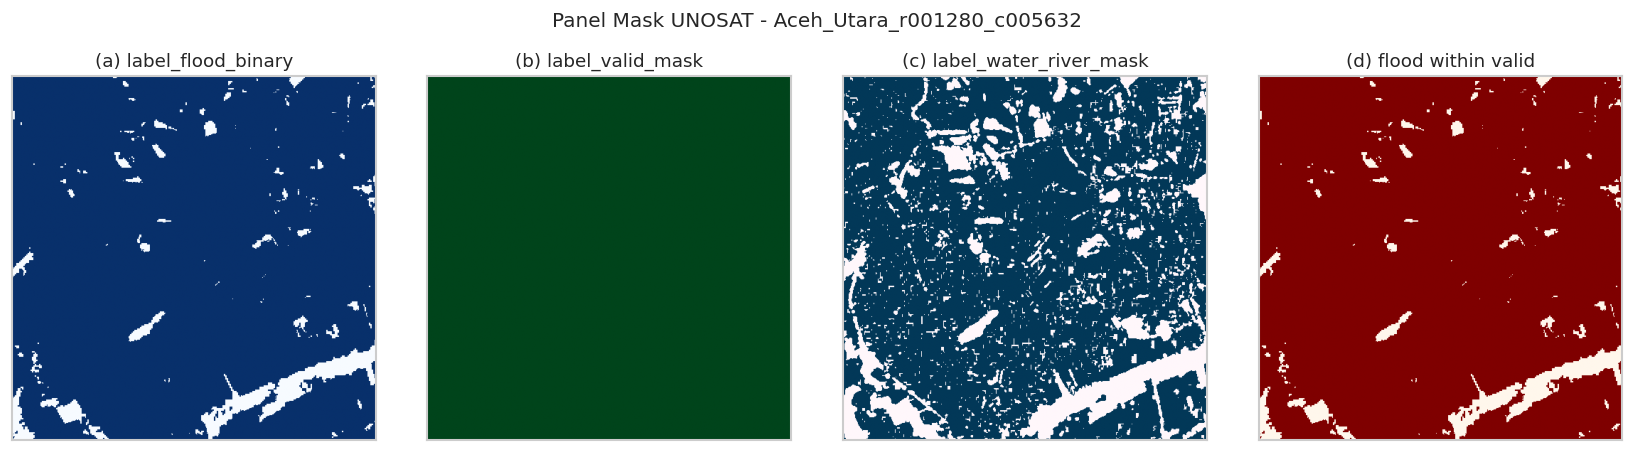

saved table: outputs/bab4/tables/4_2_unosat_mask_panel_status.csv (1 rows)


,region,tile,status,flood_pixels_valid,valid_pixels,water_river_pixels_valid,figure
0,Aceh_Utara,Aceh_Utara_r001280_c005632.npz,ok,247132,262144,208682,outputs/bab4/figures/4_2_unosat_mask_panel_ace...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_2_unosat_mask_panel_status.csv')

In [15]:
def choose_label_tile(region: str = TEST_REGION, require_flood: bool = True) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0] > 0
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)[None]))[0] > 0
            water = np.asarray(z.get("water_river_mask", np.zeros_like(y)[None]))[0] > 0
            flood_count = int((y & valid).sum())
            valid_count = int(valid.sum())
            water_count = int((water & valid).sum())
            candidates.append((flood_count, valid_count, water_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    if require_flood:
        positives = [c for c in candidates if c[0] > 0 and c[1] > 0]
        if positives:
            return sorted(positives, key=lambda x: (x[0], x[2], x[1]), reverse=True)[0][3]
    return sorted(candidates, key=lambda x: (x[1], x[2]), reverse=True)[0][3]

mask_panel_rows = []
tile_path = choose_label_tile(TEST_REGION, require_flood=True)
if tile_path is None:
    mask_panel_rows.append({"region": TEST_REGION, "status": "missing_tile"})
else:
    try:
        z = load_npz(tile_path)
        y = np.asarray(z["y"])[0] > 0
        valid = np.asarray(z.get("valid_mask", np.ones_like(y)[None]))[0] > 0
        water = np.asarray(z.get("water_river_mask", np.zeros_like(y)[None]))[0] > 0
        panels = [
            (y.astype(float), "(a) label_flood_binary", "Blues"),
            (valid.astype(float), "(b) label_valid_mask", "Greens"),
            (water.astype(float), "(c) label_water_river_mask", "PuBu"),
            ((y & valid).astype(float), "(d) flood within valid", "OrRd"),
        ]
        fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
        for ax, (image, title, cmap) in zip(axes, panels):
            ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
            ax.set_title(title)
            ax.set_xticks([])
            ax.set_yticks([])
        fig.suptitle(f"Panel Mask UNOSAT - {tile_path.stem}")
        save_fig(fig, "4_2_unosat_mask_panel_aceh_utara.png")
        mask_panel_rows.append({
            "region": TEST_REGION,
            "tile": tile_path.name,
            "status": "ok",
            "flood_pixels_valid": int((y & valid).sum()),
            "valid_pixels": int(valid.sum()),
            "water_river_pixels_valid": int((water & valid).sum()),
            "figure": "outputs/bab4/figures/4_2_unosat_mask_panel_aceh_utara.png",
        })
    except Exception as exc:
        mask_panel_rows.append({"region": TEST_REGION, "tile": tile_path.name, "status": "render_error", "note": f"{type(exc).__name__}: {exc}"})
mask_panel_status = pd.DataFrame(mask_panel_rows)
save_table(mask_panel_status, "4_2_unosat_mask_panel_status.csv")


## 4.2 Panel Mask UNOSAT - Full Wilayah Aceh Utara

Membuat panel visual `label_flood_binary`, `label_valid_mask`, dan `label_water_river_mask` pada seluruh wilayah Aceh Utara (decimated 10x).


saved figure: outputs/bab4/figures/4_2_unosat_mask_panel_aceh_utara_full.png


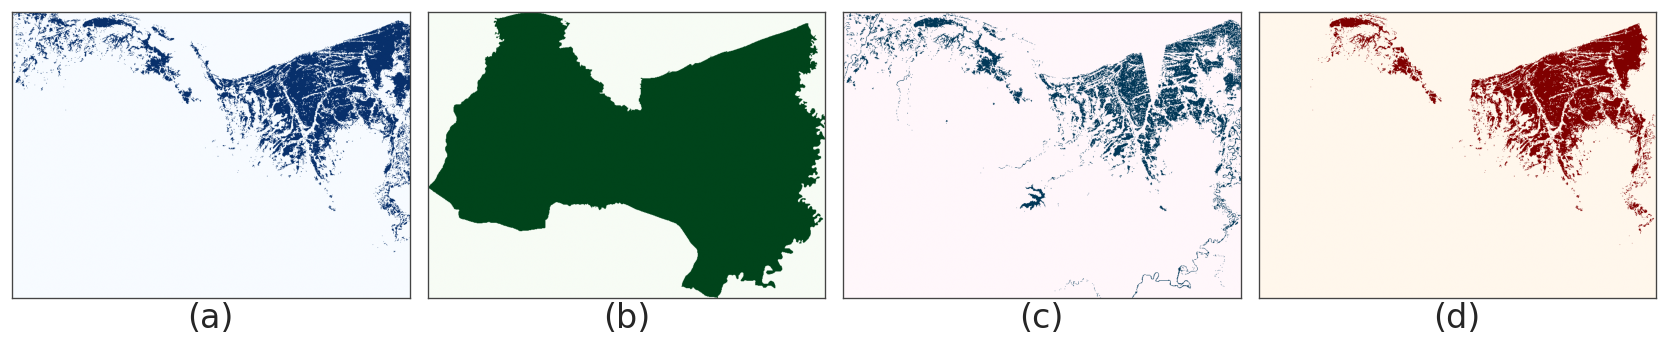

saved table: outputs/bab4/tables/4_2_unosat_mask_panel_status_full.csv (1 rows)


,region,status,flood_pixels_valid_decimated,valid_pixels_decimated,water_river_pixels_valid_decimated,figure
0,Aceh_Utara,ok,46823,270180,32581,outputs/bab4/figures/4_2_unosat_mask_panel_ace...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_2_unosat_mask_panel_status_full.csv')

In [17]:
mask_panel_full_rows = []

if rasterio is None:
    mask_panel_full_rows.append({
        "region": TEST_REGION,
        "status": "skipped",
        "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"
    })

else:
    try:
        def read_label_raster_full(region: str, layer_name: str, decimate: int = 10):
            path = DATASET / "labels_unosat_rasterized" / region / layer_name
            if not path.exists():
                return None, None

            with rasterio.open(path) as src:
                new_height = src.height // decimate
                new_width = src.width // decimate
                arr = src.read(
                    1,
                    out_shape=(new_height, new_width),
                    resampling=rasterio.enums.Resampling.nearest
                )
                extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
                return arr, extent

        y_full, extent = read_label_raster_full(TEST_REGION, "label_flood_binary.tif", decimate=10)
        valid_full, _ = read_label_raster_full(TEST_REGION, "label_valid_mask.tif", decimate=10)
        water_full, _ = read_label_raster_full(TEST_REGION, "label_water_river_mask.tif", decimate=10)

        if y_full is None or valid_full is None or water_full is None:
            mask_panel_full_rows.append({
                "region": TEST_REGION,
                "status": "missing_full_raster"
            })

        else:
            y = y_full > 0
            valid = valid_full > 0
            water = water_full > 0

            panels = [
                (y.astype(float), "Blues"),
                (valid.astype(float), "Greens"),
                (water.astype(float), "PuBu"),
                ((y & valid).astype(float), "OrRd"),
            ]

            subplot_labels = ["(a)", "(b)", "(c)", "(d)"]

            fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))

            for idx, (ax, (image, cmap)) in enumerate(zip(axes, panels)):
                ax.imshow(image, extent=extent, origin="upper", cmap=cmap, vmin=0, vmax=1)

                ax.text(
                    0.5, -0.015, subplot_labels[idx],
                    transform=ax.transAxes,
                    ha="center", va="top",
                    fontsize=20,
                    clip_on=False
                )

                ax.set_xticks([])
                ax.set_yticks([])

                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_linewidth(0.8)
                    spine.set_edgecolor("#444444")

            fig.subplots_adjust(
                left=0.03,
                right=0.98,
                top=0.98,
                bottom=0.18,
                wspace=0.08
            )

            save_fig(fig, "4_2_unosat_mask_panel_aceh_utara_full.png")

            mask_panel_full_rows.append({
                "region": TEST_REGION,
                "status": "ok",
                "flood_pixels_valid_decimated": int((y & valid).sum()),
                "valid_pixels_decimated": int(valid.sum()),
                "water_river_pixels_valid_decimated": int((water & valid).sum()),
                "figure": "outputs/bab4/figures/4_2_unosat_mask_panel_aceh_utara_full.png",
            })

    except Exception as exc:
        mask_panel_full_rows.append({
            "region": TEST_REGION,
            "status": "render_error",
            "note": f"{type(exc).__name__}: {exc}"
        })

mask_panel_status_full = pd.DataFrame(mask_panel_full_rows)
save_table(mask_panel_status_full, "4_2_unosat_mask_panel_status_full.csv")

## 4.2 Contoh Tile Positif dan Background

Membuat contoh visual tile positif dan tile background-only untuk membantu pembahasan distribusi dataset.


saved figure: outputs/bab4/figures/4_2_positive_background_tile_examples.png


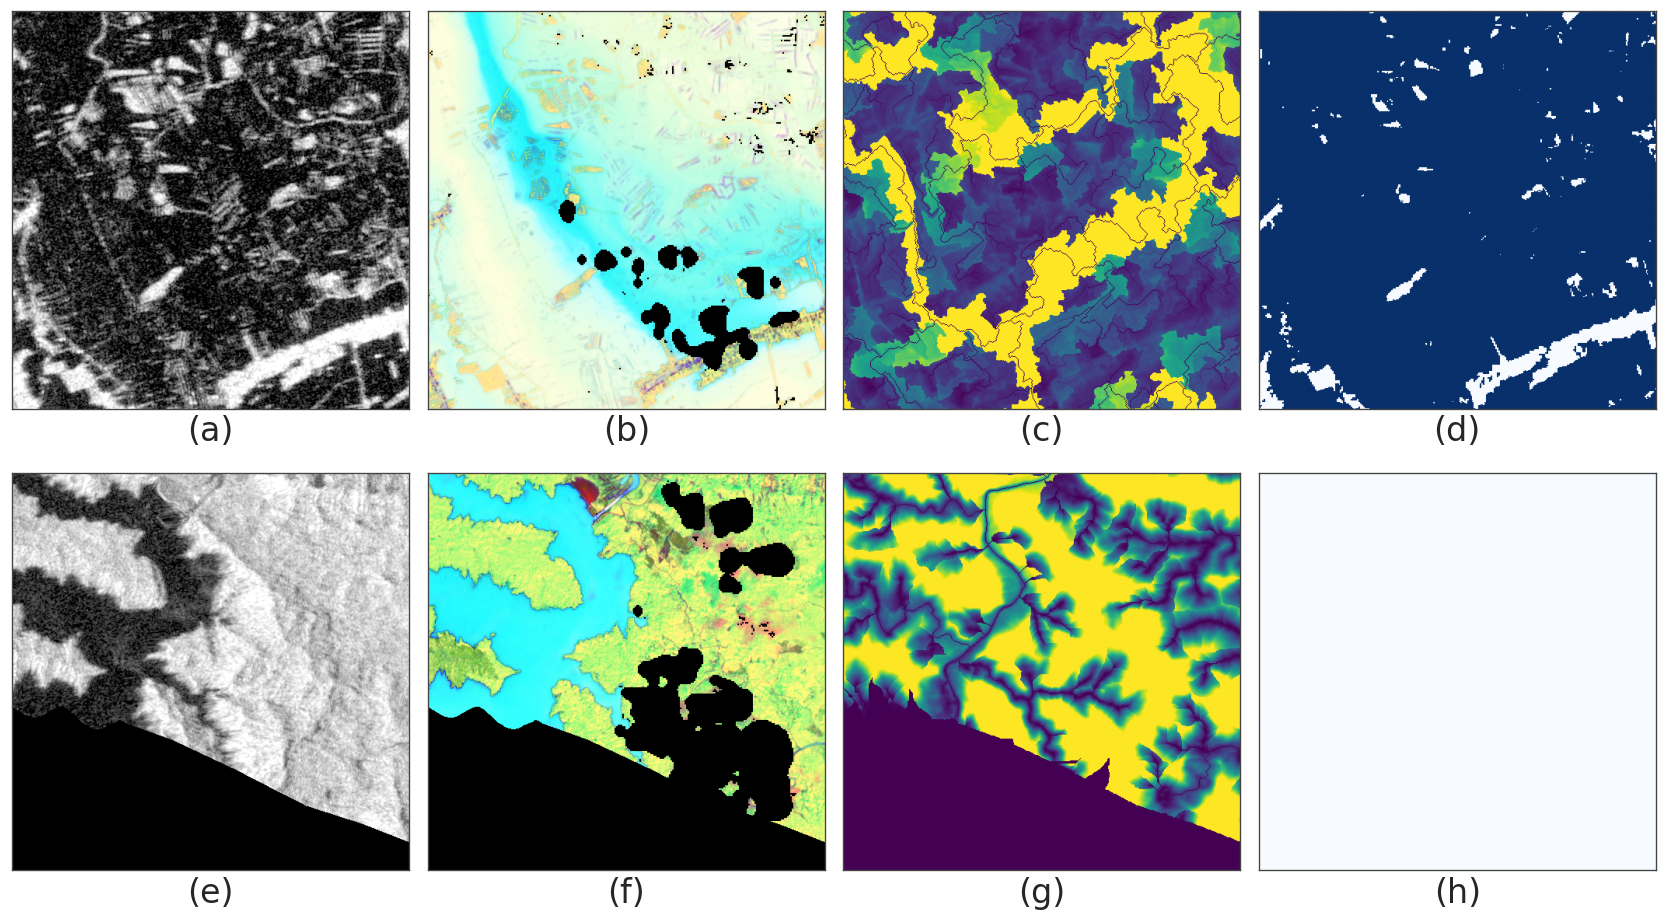

saved table: outputs/bab4/tables/4_2_positive_background_tile_examples_status.csv (2 rows)


,region,tile_type,tile,status,flood_pixels_valid,valid_pixels
0,Aceh_Utara,positive,Aceh_Utara_r001280_c005632.npz,ok,247132,262144
1,Aceh_Utara,background,Aceh_Utara_r003584_c003840.npz,ok,0,192778


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_2_positive_background_tile_examples_status.csv')

In [19]:
def choose_tile_by_label(region: str, want_positive: bool) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []

    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0] > 0
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)[None]))[0] > 0
            x = np.asarray(z["x"])

            flood_count = int((y & valid).sum())
            valid_count = int(valid.sum())
            texture = float(np.nanstd(x[0][valid])) + float(np.nanstd(x[1][valid])) if valid_count else 0.0

            candidates.append((flood_count, valid_count, texture, path))
        except Exception:
            continue

    if not candidates:
        return None

    if want_positive:
        pool = [c for c in candidates if c[0] > 0 and c[1] > 0]
        if pool:
            return sorted(pool, key=lambda x: (x[0], x[2], x[1]), reverse=True)[0][3]
    else:
        pool = [c for c in candidates if c[0] == 0 and c[1] > 0]
        if pool:
            return sorted(pool, key=lambda x: (x[2], x[1]), reverse=True)[0][3]

    return sorted(candidates, key=lambda x: (x[1], x[2]), reverse=True)[0][3]


example_rows = []
positive_tile = choose_tile_by_label(TEST_REGION, want_positive=True)
background_tile = choose_tile_by_label(TEST_REGION, want_positive=False)
example_specs = [("positive", positive_tile), ("background", background_tile)]

if all(path is None for _, path in example_specs):
    example_rows.append({
        "region": TEST_REGION,
        "status": "missing_tiles"
    })

else:
    fig, axes = plt.subplots(2, 4, figsize=(14, 8.2))
    subplot_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]

    for row_idx, (kind, path) in enumerate(example_specs):
        if path is None:
            for col_idx, ax in enumerate(axes[row_idx]):
                panel_idx = row_idx * 4 + col_idx
                ax.text(0.5, 0.5, f"No {kind} tile", ha="center", va="center")
                ax.text(
                    0.5, -0.015, subplot_labels[panel_idx],
                    transform=ax.transAxes,
                    ha="center", va="top",
                    fontsize=20,
                    clip_on=False
                )
                ax.axis("off")
            continue

        z = load_npz(path)
        x = np.asarray(z["x"])
        y = np.asarray(z["y"])[0] > 0
        valid = np.asarray(z.get("valid_mask", np.ones_like(y)[None]))[0] > 0

        hsv = np.dstack([
            normalize_image(x[4]),
            normalize_image(x[3]),
            normalize_image(x[2])
        ])

        panels = [
            (normalize_image(x[0]), "gray"),
            (hsv, None),
            (normalize_image(x[6]), "viridis"),
            ((y & valid).astype(float), "Blues"),
        ]

        for col_idx, (image, cmap) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            panel_idx = row_idx * 4 + col_idx

            if cmap:
                ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
            else:
                ax.imshow(np.clip(image, 0, 1))

            ax.text(
                0.5, -0.015, subplot_labels[panel_idx],
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=20,
                clip_on=False
            )

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)
                spine.set_edgecolor("#444444")

        example_rows.append({
            "region": TEST_REGION,
            "tile_type": kind,
            "tile": path.name,
            "status": "ok",
            "flood_pixels_valid": int((y & valid).sum()),
            "valid_pixels": int(valid.sum()),
        })

    fig.subplots_adjust(
        left=0.04,
        right=0.98,
        top=0.98,
        bottom=0.10,
        wspace=0.08,
        hspace=0.28
    )

    save_fig(fig, "4_2_positive_background_tile_examples.png")

example_tile_status = pd.DataFrame(example_rows)
save_table(example_tile_status, "4_2_positive_background_tile_examples_status.csv")

## 4.2 Narasi Interpretasi

Menyimpan paragraf siap pakai untuk menjelaskan fungsi mask, class imbalance, dan alasan valid mask penting untuk loss/evaluasi.


In [9]:
if "label_stats" in globals() and not label_stats.empty:
    ok_stats = label_stats[label_stats["status"].eq("ok")]
    max_region = ok_stats.sort_values("flood_pct_of_valid", ascending=False).iloc[0]["region"] if not ok_stats.empty else "-"
    min_region = ok_stats.sort_values("flood_pct_of_valid", ascending=True).iloc[0]["region"] if not ok_stats.empty else "-"
    median_flood_pct = float(ok_stats["flood_pct_of_valid"].median()) if not ok_stats.empty else 0.0
else:
    max_region = min_region = "-"
    median_flood_pct = 0.0

interpretation_text = f"""# Interpretasi Label UNOSAT dan Dataset Tile 4.2

Label target banjir berasal dari layer `FloodExtent`, yang pada tile tersimpan sebagai `y` atau ekuivalen dengan `label_flood_binary`. Area yang boleh memengaruhi loss dan evaluasi dibatasi oleh `AnalysisExtent`, yang tersimpan sebagai `valid_mask`. Layer `WaterExtent` dan `River` tidak digabungkan sebagai label banjir utama; keduanya dipertahankan sebagai `water_river_mask` untuk audit area air permanen dan sungai.

Statistik label menunjukkan class imbalance yang kuat antara piksel banjir dan non-banjir. Median persentase banjir terhadap area valid adalah sekitar {median_flood_pct:.4f}%. Wilayah dengan proporsi banjir terbesar pada ringkasan tile adalah {max_region}, sedangkan proporsi terkecil adalah {min_region}. Karena kelas non-banjir mendominasi, IoU dan Dice/F1 lebih informatif daripada akurasi saja.

Dataset tile dibuat dari citra 512 x 512 piksel. Tile positif dipertahankan untuk menjaga sinyal banjir, sedangkan tile background-only digunakan sebagai konteks non-banjir dan perlu dibaca bersama rasio positif-background pada tabel distribusi tile. Valid mask penting karena piksel di luar area analisis UNOSAT tidak seharusnya dihitung sebagai kesalahan model.
"""

narrative_path = NARRATIVE_DIR / "4_2_label_tile_interpretation.md"
narrative_path.write_text(interpretation_text, encoding="utf-8")
print(f"saved narrative: {narrative_path.relative_to(ROOT)}")
print(interpretation_text)
narrative_path


saved narrative: outputs/bab4/narratives/4_2_label_tile_interpretation.md
# Interpretasi Label UNOSAT dan Dataset Tile 4.2

Label target banjir berasal dari layer `FloodExtent`, yang pada tile tersimpan sebagai `y` atau ekuivalen dengan `label_flood_binary`. Area yang boleh memengaruhi loss dan evaluasi dibatasi oleh `AnalysisExtent`, yang tersimpan sebagai `valid_mask`. Layer `WaterExtent` dan `River` tidak digabungkan sebagai label banjir utama; keduanya dipertahankan sebagai `water_river_mask` untuk audit area air permanen dan sungai.

Statistik label menunjukkan class imbalance yang kuat antara piksel banjir dan non-banjir. Median persentase banjir terhadap area valid adalah sekitar 5.5702%. Wilayah dengan proporsi banjir terbesar pada ringkasan tile adalah Aceh_Utara, sedangkan proporsi terkecil adalah Pasaman_Barat. Karena kelas non-banjir mendominasi, IoU dan Dice/F1 lebih informatif daripada akurasi saja.

Dataset tile dibuat dari citra 512 x 512 piksel. Tile positif dipertahan

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/narratives/4_2_label_tile_interpretation.md')

## Checklist 4.2

Memverifikasi artefak 4.2 yang diminta TODO.


In [10]:
expected = [
    ("wajib", "Statistik label UNOSAT per wilayah", TABLE_DIR / "4_2_label_mask_tile_stats.csv"),
    ("wajib", "Panel mask UNOSAT: flood, valid, water/river", FIG_DIR / "4_2_unosat_mask_panel_aceh_utara.png"),
    ("wajib", "Status panel mask UNOSAT", TABLE_DIR / "4_2_unosat_mask_panel_status.csv"),
    ("wajib", "Jumlah tile positif/background per wilayah/split", TABLE_DIR / "4_2_tile_distribution_by_split_region.csv"),
    ("disarankan", "Bar chart persentase banjir per wilayah", FIG_DIR / "4_2_flood_label_distribution.png"),
    ("wajib", "Mapping fungsi layer UNOSAT", TABLE_DIR / "4_2_unosat_source_layer_mapping.csv"),
    ("opsional", "Contoh tile positif dan background-only", FIG_DIR / "4_2_positive_background_tile_examples.png"),
    ("opsional", "Status contoh tile positif/background", TABLE_DIR / "4_2_positive_background_tile_examples_status.csv"),
    ("narasi_wajib", "Penjelasan fungsi mask dan class imbalance", NARRATIVE_DIR / "4_2_label_tile_interpretation.md"),
]
checklist_4_2 = pd.DataFrame([
    {
        "priority": priority,
        "todo_item": todo_item,
        "artifact": str(path.relative_to(ROOT)),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    }
    for priority, todo_item, path in expected
])
save_table(checklist_4_2, "4_2_todo_coverage_checklist.csv")
missing = checklist_4_2[~checklist_4_2["exists"]]
if missing.empty:
    print("All 4.2 TODO artifacts created.")
else:
    print("Missing 4.2 artifacts:")
    display(missing)


saved table: outputs/bab4/tables/4_2_todo_coverage_checklist.csv (9 rows)


,priority,todo_item,artifact,exists,size_bytes
0,wajib,Statistik label UNOSAT per wilayah,outputs/bab4/tables/4_2_label_mask_tile_stats.csv,True,1260
1,wajib,"Panel mask UNOSAT: flood, valid, water/river",outputs/bab4/figures/4_2_unosat_mask_panel_ace...,True,1134324
2,wajib,Status panel mask UNOSAT,outputs/bab4/tables/4_2_unosat_mask_panel_stat...,True,207
3,wajib,Jumlah tile positif/background per wilayah/split,outputs/bab4/tables/4_2_tile_distribution_by_s...,True,1102
4,disarankan,Bar chart persentase banjir per wilayah,outputs/bab4/figures/4_2_flood_label_distribut...,True,158746
5,wajib,Mapping fungsi layer UNOSAT,outputs/bab4/tables/4_2_unosat_source_layer_ma...,True,542
6,opsional,Contoh tile positif dan background-only,outputs/bab4/figures/4_2_positive_background_t...,True,6332054
7,opsional,Status contoh tile positif/background,outputs/bab4/tables/4_2_positive_background_ti...,True,194
8,narasi_wajib,Penjelasan fungsi mask dan class imbalance,outputs/bab4/narratives/4_2_label_tile_interpr...,True,1218


All 4.2 TODO artifacts created.
